# 1. Setting up the Environment

---

## 1.1 Installing the Required Packages

In [1]:
# 1. Install wget and pydub
!pip install -q wget pydub

# 2. Install deepmultilingualpunctuation
!pip install -q deepmultilingualpunctuation

# 3. Install NeMo toolkit for ASR (Automatic Speech Recognition)
!pip install -q --no-build-isolation nemo_toolkit[asr]

# 4. Install OpenUnmix and its dependencies
!pip install -q dora-search "lameenc>=1.2" openunmix

# 5. Install Demucs
!pip install -q --no-deps demucs

# 6. Install WhisperX
!git clone https://github.com/m-bain/whisperX.git
%cd whisperX
!pip install -e .

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.5/70.5 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.3/180.3 kB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 843.9/843.9 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.0/811.0 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.8/419.8 kB 33.4 MB/s 

## 1.2 Importing the Libraries

In [2]:
# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Standard library imports
import os
import json
import shutil
import re
import logging
import matplotlib.pyplot as plt
import numpy as np

# Third-party library imports
import wget
import IPython
import librosa
from omegaconf import OmegaConf
from pydub import AudioSegment
from faster_whisper import WhisperModel
import whisperx
import torch
from nemo.collections.asr.models.msdd_models import NeuralDiarizer
from deepmultilingualpunctuation import PunctuationModel
import nltk

# WhisperX-specific imports
from whisperx.alignment import DEFAULT_ALIGN_MODELS_HF, DEFAULT_ALIGN_MODELS_TORCH
from whisperx.utils import LANGUAGES, TO_LANGUAGE_CODE

## 1.3 Some Basic Definitions and Helper Functions

In [3]:
punctuation_model_languages = ["en"]
wav2vec2_langs = list(DEFAULT_ALIGN_MODELS_TORCH.keys()) + list(DEFAULT_ALIGN_MODELS_HF.keys())
whisper_langs = sorted(LANGUAGES.keys()) + sorted([k.title() for k in TO_LANGUAGE_CODE.keys()])

sentence_ending_punctuations = ".?!"


def get_first_word_idx_of_sentence(word_idx, word_list, speaker_list, max_words):
    """
    Finds the first word index of a sentence.
    """
    is_word_sentence_end = lambda x: x >= 0 and word_list[x][-1] in sentence_ending_punctuations
    left_idx = word_idx
    
    while (
        left_idx > 0
        and word_idx - left_idx < max_words
        and speaker_list[left_idx - 1] == speaker_list[left_idx]
        and not is_word_sentence_end(left_idx - 1)
    ):
        left_idx -= 1

    return left_idx if left_idx == 0 or is_word_sentence_end(left_idx - 1) else -1


def get_last_word_idx_of_sentence(word_idx, word_list, max_words):
    """
    Finds the last word index of a sentence.
    """
    is_word_sentence_end = lambda x: x >= 0 and word_list[x][-1] in sentence_ending_punctuations
    right_idx = word_idx
    
    while (
        right_idx < len(word_list)
        and right_idx - word_idx < max_words
        and not is_word_sentence_end(right_idx)
    ):
        right_idx += 1

    return right_idx if right_idx == len(word_list) - 1 or is_word_sentence_end(right_idx) else -1


def get_sentences_speaker_mapping(word_speaker_mapping, spk_ts):
    """
    Creates sentence-level speaker mappings.
    """
    sentence_checker = nltk.tokenize.PunktSentenceTokenizer().text_contains_sentbreak
    s, e, spk = spk_ts[0]
    prev_spk = spk

    snts = []
    snt = {"speaker": f"Speaker {spk}", "start_time": s, "end_time": e, "text": ""}

    for wrd_dict in word_speaker_mapping:
        wrd, spk = wrd_dict["word"], wrd_dict["speaker"]
        s, e = wrd_dict["start_time"], wrd_dict["end_time"]
        
        if spk != prev_spk or sentence_checker(snt["text"] + " " + wrd):
            snts.append(snt)
            snt = {"speaker": f"Speaker {spk}", "start_time": s, "end_time": e, "text": ""}
        else:
            snt["end_time"] = e
        
        snt["text"] += wrd + " "
        prev_spk = spk

    snts.append(snt)
    return snts

def find_numeral_symbol_tokens(tokenizer):
    """
    Identifies tokens in the tokenizer vocabulary that contain numeral symbols.
    """
    numeral_symbol_tokens = [-1]
    
    for token, token_id in tokenizer.get_vocab().items():
        has_numeral_symbol = any(c in "0123456789%$£" for c in token)
        if has_numeral_symbol:
            numeral_symbol_tokens.append(token_id)
    
    return numeral_symbol_tokens


def filter_missing_timestamps(word_timestamps, initial_timestamp=0, final_timestamp=None):
    """
    Filter and fill in missing timestamps for word entries.
    """
    result = []

    first_word = word_timestamps[0]
    if first_word.get("start") is None:
        first_word["start"] = initial_timestamp if initial_timestamp is not None else 0
        first_word["end"] = _get_next_start_timestamp(word_timestamps, 0, final_timestamp)
    result.append(first_word)

    # Process subsequent words
    for i, current_word in enumerate(word_timestamps[1:], start=1):
        if current_word.get("start") is None and current_word.get("word") is not None:
            previous_word = word_timestamps[i - 1]
            current_word["start"] = previous_word["end"]
            current_word["end"] = _get_next_start_timestamp(word_timestamps, i, final_timestamp)

        if current_word["word"] is not None:
            result.append(current_word)

    return result


def _get_next_start_timestamp(word_timestamps, current_word_index, final_timestamp):
    """
    Returns the next start timestamp based on the current word index.
    """
    if current_word_index == len(word_timestamps) - 1:
        return word_timestamps[current_word_index]["start"]

    next_word_index = current_word_index + 1
    while current_word_index < len(word_timestamps) - 1:
        if word_timestamps[next_word_index].get("start") is None:
            word_timestamps[current_word_index]["word"] += " " + word_timestamps[next_word_index]["word"]
            word_timestamps[next_word_index]["word"] = None
            next_word_index += 1
            if next_word_index == len(word_timestamps):
                return final_timestamp
        else:
            return word_timestamps[next_word_index]["start"]


def process_language_arg(language: str, model_name: str):
    """
    Processes the language argument and returns the corresponding language code.
    """
    if language is not None:
        language = language.lower()
    if language not in LANGUAGES:
        if language in TO_LANGUAGE_CODE:
            language = TO_LANGUAGE_CODE[language]
        else:
            raise ValueError(f"Unsupported language: {language}")

    if model_name.endswith(".en") and language != "en":
        if language is not None:
            logging.warning(f"{model_name} is an English-only model but received '{language}'; using English instead.")
        language = "en"
    
    return language

# 2. Pre-processing the Audio

---

## 2.1 Setting up the Basic Configuration

In [4]:
config = {
    'audio_path': "/kaggle/input/audios/audio.mp3",
    'enable_stemming': True, 
    'whisper_model_name': "turbo",  
    'suppress_numerals': True, 
    'batch_size': 32,  
    'language': 'en',  
    'device': "cpu"  
}

config['device'] = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Configuration: {config}")

Configuration: {'audio_path': '/kaggle/input/audios/audio.mp3', 'enable_stemming': True, 'whisper_model_name': 'turbo', 'suppress_numerals': True, 'batch_size': 32, 'language': 'en', 'device': 'cuda'}


## 2.2 Visualising the Audio

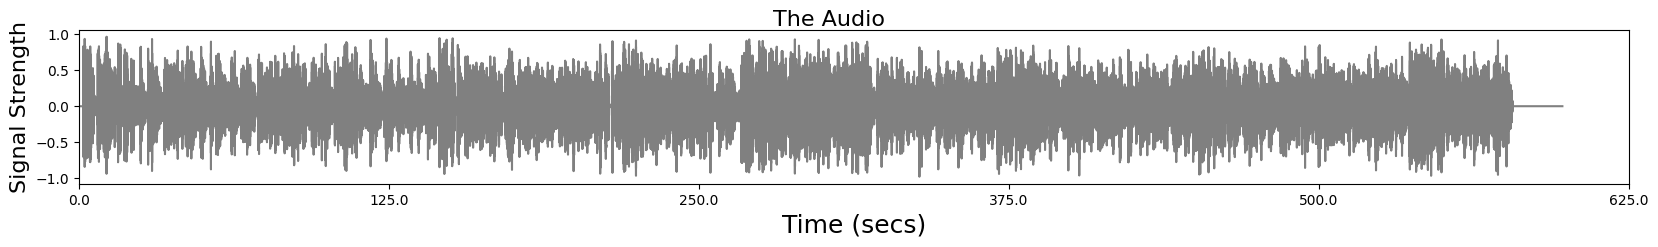

In [5]:
audio_path = '/kaggle/input/audios/audio.mp3'

sr = 16000
signal, sr = librosa.load(audio_path, sr=sr) 

fig, ax = plt.subplots(1, 1)
fig.set_figwidth(20)
fig.set_figheight(2)
plt.plot(np.arange(len(signal)), signal, 'gray')
fig.suptitle('The Audio', fontsize=16)
plt.xlabel('Time (secs)', fontsize=18)
ax.margins(x=0)
plt.ylabel('Signal Strength', fontsize=16)
a, _ = plt.xticks()
plt.xticks(a, a/sr)

plt.show()

## 2.3 Isolating the Vocals using Demucs

In [6]:
"""
This code handles vocal isolation from the provided audio file. 
If stemming is enabled, it attempts to separate vocals using the Demucs model. 
If the separation is successful, the vocals are saved to a new file; otherwise, the original audio file is used.
"""

def get_vocal_target(enable_stemming: bool, audio_path: str) -> str:
    """
    Returns the path to the vocals if stemming is enabled, otherwise the original audio path.
    """
    if enable_stemming:
        separation_result = separate_vocals(audio_path)
        if separation_result is None:
            logging.warning("Vocal separation failed. Using the original audio.")
            return audio_path  
        return separation_result
    return audio_path  


def separate_vocals(audio_path: str) -> str:
    """
    Attempts to isolate vocals from the audio using the Demucs model.
    If successful, returns the path to the separated vocals; otherwise, None.
    """
    separation_command = f'python3 -m demucs.separate -n htdemucs --two-stems=vocals "{audio_path}" -o "temp_outputs"'
    separation_status = os.system(separation_command)

    if separation_status == 0:
        return os.path.join(
            "temp_outputs",
            "htdemucs",
            os.path.splitext(os.path.basename(audio_path))[0],
            "vocals.wav",
        )
    return None
    

enable_stemming = True
vocal_target = get_vocal_target(enable_stemming, audio_path)

# 3. Transcribing the Audio

---

## 3.1 Configuring Whisper

In [7]:
whisper_model_name = config['whisper_model_name']
suppress_numerals = config['suppress_numerals']
batch_size = config['batch_size']
language = config['language']
device = config['device']

## 3.2 Helper Functions for Transcribing

In [8]:
def transcribe(audio_file: str, language: str, model_name: str, compute_dtype: str, suppress_numerals: bool, device: str):
    """
    Transcribes an audio file using the specified model.
    """
    from faster_whisper import WhisperModel
    from helpers import find_numeral_symbol_tokens, wav2vec2_langs

    whisper_model = WhisperModel(model_name, device=device, compute_type=compute_dtype)

    if suppress_numerals:
        numeral_symbol_tokens = find_numeral_symbol_tokens(whisper_model.hf_tokenizer)
    else:
        numeral_symbol_tokens = None

    word_timestamps = not(language in wav2vec2_langs)
    
    segments, info = whisper_model.transcribe(
        audio_file,
        language=language,
        beam_size=5,
        word_timestamps=word_timestamps,  
        suppress_tokens=numeral_symbol_tokens,
        vad_filter=True,
    )

    whisper_results = [segment._asdict() for segment in segments]
    
    del whisper_model
    torch.cuda.empty_cache()
    
    return whisper_results, language


def transcribe_batch(audio_file: str, language: str, batch_size: int, model_name: str, compute_dtype: str, suppress_numerals: bool, device: str):
    """
    Transcribes an audio file in batches using the specified model.
    """
    import whisperx

    whisper_model = whisperx.load_model(
        model_name,
        device,
        compute_type=compute_dtype,
        asr_options={"suppress_numerals": suppress_numerals},
    )
    
    audio = whisperx.load_audio(audio_file)
    result = whisper_model.transcribe(audio, language=language, batch_size=batch_size)
    
    del whisper_model
    torch.cuda.empty_cache()
    
    return result["segments"], result["language"]

## 3.3 The Transcription Process

In [9]:
"""
This block handles the transcription process, choosing between batch and single transcription
based on the `batch_size` parameter.
"""

compute_type = "float16"

transcribe_fn = transcribe_batch if batch_size != 0 else transcribe

whisper_results, language = transcribe_fn(
    vocal_target,
    language,
    batch_size if batch_size != 0 else None,
    whisper_model_name,
    compute_type,
    suppress_numerals,
    device,
)

vocabulary.json:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/340 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/2.26k [00:00<?, ?B/s]

model.bin:   0%|          | 0.00/1.62G [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.71M [00:00<?, ?B/s]

No language specified, language will be first be detected for each audio file (increases inference time).
>>Performing voice activity detection using Pyannote...
Model was trained with pyannote.audio 0.0.1, yours is 3.3.2. Bad things might happen unless you revert pyannote.audio to 0.x.
Model was trained with torch 1.10.0+cu102, yours is 2.5.1+cu121. Bad things might happen unless you revert torch to 1.x.
Suppressing numeral and symbol tokens


# 4. Aligning the Timestamps

---

In [10]:
"""
This block performs alignment of transcribed words with timestamps using the wav2vec2 model.
If the language is supported, it uses WhisperX for alignment and timestamp extraction. 
If not, it directly uses the timestamps provided by Whisper for unsupported languages.
"""

if language in wav2vec2_langs:
    device = "cuda"
    
    align_model, metadata = whisperx.load_align_model(language_code=language, device=device)
    
    result_aligned = whisperx.align(whisper_results, align_model, metadata, vocal_target, device)
    
    word_timestamps = filter_missing_timestamps(
        result_aligned["word_segments"],
        initial_timestamp=whisper_results[0].get("start"),
        final_timestamp=whisper_results[-1].get("end"),
    )

    align_model = None
    torch.cuda.empty_cache()

else:
    assert batch_size == 0, (
        f"Unsupported language: {language}, set --batch_size to 0 to generate word timestamps "
        "using Whisper directly and fix this error."
    )
    
    word_timestamps = []
    for segment in whisper_results:
        for word in segment["words"]:
            word_timestamps.append({"word": word[2], "start": word[0], "end": word[1]})

Downloading: "https://download.pytorch.org/torchaudio/models/wav2vec2_fairseq_base_ls960_asr_ls960.pth" to /root/.cache/torch/hub/checkpoints/wav2vec2_fairseq_base_ls960_asr_ls960.pth
100%|██████████| 360M/360M [00:01<00:00, 257MB/s] 


# 5. Noting the Transcription Results

---

In [11]:
"""
Writes the transcription results to a text file in a structured format.
Each entry includes the transcribed text, start time, and end time.
"""

with open("transcription.txt", "w", encoding="utf-8") as txt:
    for result in whisper_results:
        txt.write(f"""\n{{
    "text": "{result["text"]}",
    "start": {result["start"]},
    "end": {result["end"]}
}}\n""")

# 6. Diarizing the Audio 

---

## 6.1 Making the Audio NeMo Compatible

In [12]:
"""
This block converts the input audio file into a mono format for compatibility with the NeMo model, 
and saves the mono audio as a WAV file in the temporary directory.
"""

audio = AudioSegment.from_file(vocal_target).set_channels(1)

ROOT = os.getcwd()
temp_path = os.path.join(ROOT, "temp_outputs")

os.makedirs(temp_path, exist_ok=True)

audio.export(os.path.join(temp_path, "mono_ready.wav"), format="wav")

<_io.BufferedRandom name='/kaggle/working/whisperX/temp_outputs/mono_ready.wav'>

## 6.2 Helper Function to Create Config for Diarizer

In [13]:
def create_config(output_dir):
    """
    Creates configuration for diarization based on the domain type.
    """
    DOMAIN_TYPE = "telephonic"  
    CONFIG_FILE_NAME = f"diar_infer_{DOMAIN_TYPE}.yaml"
    CONFIG_URL = f"https://raw.githubusercontent.com/NVIDIA/NeMo/main/examples/speaker_tasks/diarization/conf/inference/{CONFIG_FILE_NAME}"
    MODEL_CONFIG = os.path.join(output_dir, CONFIG_FILE_NAME)
    
    if not os.path.exists(MODEL_CONFIG):
        MODEL_CONFIG = wget.download(CONFIG_URL, output_dir)
    
    config = OmegaConf.load(MODEL_CONFIG)
    
    data_dir = os.path.join(output_dir, "data")
    os.makedirs(data_dir, exist_ok=True)
    
    meta = {
        "audio_filepath": os.path.join(output_dir, "mono_ready.wav"),
        "offset": 0,
        "duration": None,
        "label": "infer",
        "text": "-",
        "rttm_filepath": None,
        "uem_filepath": None,
    }
    
    with open(os.path.join(data_dir, "input_manifest.json"), "w") as fp:
        json.dump(meta, fp)
        fp.write("\n")
    
    pretrained_vad = "vad_multilingual_marblenet"
    pretrained_speaker_model = "titanet_large"
    
    config.num_workers = 0  
    config.diarizer.manifest_filepath = os.path.join(data_dir, "input_manifest.json")
    config.diarizer.out_dir = output_dir  
    config.diarizer.speaker_embeddings.model_path = pretrained_speaker_model
    config.diarizer.oracle_vad = False
    config.diarizer.clustering.parameters.oracle_num_speakers = False
    config.diarizer.vad.model_path = pretrained_vad
    config.diarizer.vad.parameters.onset = 0.8
    config.diarizer.vad.parameters.offset = 0.6
    config.diarizer.vad.parameters.pad_offset = -0.05
    config.diarizer.msdd_model.model_path = "diar_msdd_telephonic"
    
    return config

## 6.3 Running the Diarization Model

In [14]:
"""
Initialize and run neural diarization on the given audio file.
"""

nd_model = NeuralDiarizer(cfg=create_config(temp_path)).to("cuda")  # Load model to GPU
nd_model.diarize()  

nd_model = None  
torch.cuda.empty_cache()  

[NeMo I 2025-02-02 14:10:43 msdd_models:1120] Loading pretrained diar_msdd_telephonic model from NGC
[NeMo I 2025-02-02 14:10:43 cloud:68] Downloading from: https://api.ngc.nvidia.com/v2/models/nvidia/nemo/diar_msdd_telephonic/versions/1.0.1/files/diar_msdd_telephonic.nemo to /root/.cache/torch/NeMo/NeMo_2.1.0/diar_msdd_telephonic/3c3697a0a46f945574fa407149975a13/diar_msdd_telephonic.nemo
[NeMo I 2025-02-02 14:10:44 common:826] Instantiating model from pre-trained checkpoint


[NeMo W 2025-02-02 14:10:46 modelPT:176] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    manifest_filepath: null
    emb_dir: null
    sample_rate: 16000
    num_spks: 2
    soft_label_thres: 0.5
    labels: null
    batch_size: 15
    emb_batch_size: 0
    shuffle: true
    
[NeMo W 2025-02-02 14:10:46 modelPT:183] If you intend to do validation, please call the ModelPT.setup_validation_data() or ModelPT.setup_multiple_validation_data() method and provide a valid configuration file to setup the validation data loader(s). 
    Validation config : 
    manifest_filepath: null
    emb_dir: null
    sample_rate: 16000
    num_spks: 2
    soft_label_thres: 0.5
    labels: null
    batch_size: 15
    emb_batch_size: 0
    shuffle: false
    
[NeMo W 2025-02-02 14:10:46 modelPT:189] Please call the ModelPT.setup_test_data() or ModelPT.setup_multiple

[NeMo I 2025-02-02 14:10:46 features:305] PADDING: 16
[NeMo I 2025-02-02 14:10:46 features:305] PADDING: 16
[NeMo I 2025-02-02 14:10:46 save_restore_connector:275] Model EncDecDiarLabelModel was successfully restored from /root/.cache/torch/NeMo/NeMo_2.1.0/diar_msdd_telephonic/3c3697a0a46f945574fa407149975a13/diar_msdd_telephonic.nemo.
[NeMo I 2025-02-02 14:10:47 features:305] PADDING: 16
[NeMo I 2025-02-02 14:10:47 clustering_diarizer:117] Loading pretrained vad_multilingual_marblenet model from NGC
[NeMo I 2025-02-02 14:10:47 cloud:68] Downloading from: https://api.ngc.nvidia.com/v2/models/nvidia/nemo/vad_multilingual_marblenet/versions/1.10.0/files/vad_multilingual_marblenet.nemo to /root/.cache/torch/NeMo/NeMo_2.1.0/vad_multilingual_marblenet/670f425c7f186060b7a7268ba6dfacb2/vad_multilingual_marblenet.nemo
[NeMo I 2025-02-02 14:10:47 common:826] Instantiating model from pre-trained checkpoint


[NeMo W 2025-02-02 14:10:47 modelPT:176] If you intend to do training or fine-tuning, please call the ModelPT.setup_training_data() method and provide a valid configuration file to setup the train data loader.
    Train config : 
    manifest_filepath: /manifests/ami_train_0.63.json,/manifests/freesound_background_train.json,/manifests/freesound_laughter_train.json,/manifests/fisher_2004_background.json,/manifests/fisher_2004_speech_sampled.json,/manifests/google_train_manifest.json,/manifests/icsi_all_0.63.json,/manifests/musan_freesound_train.json,/manifests/musan_music_train.json,/manifests/musan_soundbible_train.json,/manifests/mandarin_train_sample.json,/manifests/german_train_sample.json,/manifests/spanish_train_sample.json,/manifests/french_train_sample.json,/manifests/russian_train_sample.json
    sample_rate: 16000
    labels:
    - background
    - speech
    batch_size: 256
    shuffle: true
    is_tarred: false
    tarred_audio_filepaths: null
    tarred_shard_strategy: sca

[NeMo I 2025-02-02 14:10:47 features:305] PADDING: 16
[NeMo I 2025-02-02 14:10:48 save_restore_connector:275] Model EncDecClassificationModel was successfully restored from /root/.cache/torch/NeMo/NeMo_2.1.0/vad_multilingual_marblenet/670f425c7f186060b7a7268ba6dfacb2/vad_multilingual_marblenet.nemo.
[NeMo I 2025-02-02 14:10:48 msdd_models:892] Multiscale Weights: [1, 1, 1, 1, 1]
[NeMo I 2025-02-02 14:10:48 msdd_models:893] Clustering Parameters: {
        "oracle_num_speakers": false,
        "max_num_speakers": 8,
        "enhanced_count_thres": 80,
        "max_rp_threshold": 0.25,
        "sparse_search_volume": 30,
        "maj_vote_spk_count": false,
        "chunk_cluster_count": 50,
        "embeddings_per_chunk": 10000
    }
[NeMo I 2025-02-02 14:10:48 speaker_utils:92] Number of files to diarize: 1
[NeMo I 2025-02-02 14:10:48 clustering_diarizer:303] Split long audio file to avoid CUDA memory issue


...

[NeMo I 2025-02-02 14:11:10 speaker_utils:92] Number of files to diarize: 1


[NeMo W 2025-02-02 14:11:10 der:217] Check if each ground truth RTTMs were present in the provided manifest file. Skipping calculation of Diariazation Error Rate


[NeMo I 2025-02-02 14:11:10 speaker_utils:92] Number of files to diarize: 1


[NeMo W 2025-02-02 14:11:10 der:217] Check if each ground truth RTTMs were present in the provided manifest file. Skipping calculation of Diariazation Error Rate


[NeMo I 2025-02-02 14:11:10 msdd_models:1473]   
    


# 7. Post-processing

---

## 7.1 Helper Functions for Mapping the Timestamps

In [15]:
def get_word_ts_anchor(s, e, option="start"):
    """
    Returns the timestamp anchor based on the given option (start, mid, or end).
    """
    if option == "end":
        return e
    elif option == "mid":
        return (s + e) / 2
    return s


def get_words_speaker_mapping(wrd_ts, spk_ts, word_anchor_option="start"):
    """
    Maps words with their respective speaker based on timestamps.
    """
    s, e, sp = spk_ts[0]
    wrd_pos, turn_idx = 0, 0
    wrd_spk_mapping = []
    
    for wrd_dict in wrd_ts:
        ws, we, wrd = int(wrd_dict["start"] * 1000), int(wrd_dict["end"] * 1000), wrd_dict["word"]
        wrd_pos = get_word_ts_anchor(ws, we, word_anchor_option)
        
        while wrd_pos > float(e):
            turn_idx += 1
            turn_idx = min(turn_idx, len(spk_ts) - 1)
            s, e, sp = spk_ts[turn_idx]
            if turn_idx == len(spk_ts) - 1:
                e = get_word_ts_anchor(ws, we, option="end")
        
        wrd_spk_mapping.append(
            {"word": wrd, "start_time": ws, "end_time": we, "speaker": sp}
        )
    
    return wrd_spk_mapping

## 7.2 Mapping the Speaker Timestamps

In [16]:
"""
This block reads speaker timestamps from a .rttm file, calculates the start and end times in milliseconds, and stores them in the spkr_timestamps list.
It then maps the word timestamps to speakers using the get_words_speaker_mapping function.
"""

spkr_timestamps = []
rttm_path = os.path.join(temp_path, "pred_rttms", "mono_ready.rttm")

with open(rttm_path, "r") as f:
    lines = f.readlines()
    for line in lines:
        line_data = line.split(" ")
        start_time_ms = int(float(line_data[5]) * 1000)
        end_time_ms = start_time_ms + int(float(line_data[8]) * 1000)
        spkr_timestamps.append([start_time_ms, end_time_ms, int(line_data[11].split("_")[-1])])

word_speaker_map = get_words_speaker_mapping(word_timestamps, spkr_timestamps, "start")

## 7.3 Punctuation Restoration

### 7.3.1 Helper Functions for Restoring the Punctuations

In [17]:
def get_realigned_ws_mapping_with_punctuation(word_speaker_mapping, max_words_in_sentence=50):
    """
    Realigns word speaker mappings considering sentence boundaries and punctuation.
    """
    is_word_sentence_end = lambda x: x >= 0 and word_speaker_mapping[x]["word"][-1] in sentence_ending_punctuations
    wsp_len = len(word_speaker_mapping)

    words_list, speaker_list = [], []
    
    for k, line_dict in enumerate(word_speaker_mapping):
        word, speaker = line_dict["word"], line_dict["speaker"]
        words_list.append(word)
        speaker_list.append(speaker)

    k = 0
    while k < len(word_speaker_mapping):
        line_dict = word_speaker_mapping[k]
        if (
            k < wsp_len - 1
            and speaker_list[k] != speaker_list[k + 1]
            and not is_word_sentence_end(k)
        ):
            left_idx = get_first_word_idx_of_sentence(k, words_list, speaker_list, max_words_in_sentence)
            right_idx = (
                get_last_word_idx_of_sentence(k, words_list, max_words_in_sentence - k + left_idx - 1)
                if left_idx > -1
                else -1
            )
            if min(left_idx, right_idx) == -1:
                k += 1
                continue

            spk_labels = speaker_list[left_idx : right_idx + 1]
            mod_speaker = max(set(spk_labels), key=spk_labels.count)
            if spk_labels.count(mod_speaker) < len(spk_labels) // 2:
                k += 1
                continue

            speaker_list[left_idx : right_idx + 1] = [mod_speaker] * (right_idx - left_idx + 1)
            k = right_idx

        k += 1

    k, realigned_list = 0, []
    
    while k < len(word_speaker_mapping):
        line_dict = word_speaker_mapping[k].copy()
        line_dict["speaker"] = speaker_list[k]
        realigned_list.append(line_dict)
        k += 1

    return realigned_list

### 7.3.2 Restoring the Punctuations

In [18]:
"""
This block restores punctuation in the transcript if the language is supported. 
It uses a punctuation model to predict punctuation marks for each word, applying corrections where necessary (e.g., ensuring acronyms aren't wrongly punctuated). 
If punctuation restoration isn't available, a warning is logged. 
Finally, it updates the word and sentence mappings with the restored punctuation.
"""

if language in punctuation_model_languages:
    punctuation_model = PunctuationModel(model="allenai/longformer-large-4096")

    words_list = [word_dict["word"] for word_dict in word_speaker_map]

    if words_list:
        labeled_words = punctuation_model.predict(words_list)

        ending_puncts = {".", "?", "!"}
        model_puncts = {".", ",", ";", ":", "!", "?"}

        isAcro = lambda w: re.fullmatch(r"\b(?:[a-zA-Z]\.){2,}", w)

        for word_dict, (word, punct, prob) in zip(word_speaker_map, labeled_words):
            if word and punct in ending_puncts and (word[-1] not in model_puncts or isAcro(word)):
                word = word.rstrip(".") if word.endswith("..") else word + punct
                word_dict["word"] = word
    else:
        logging.warning("words_list is empty, skipping punctuation restoration.")

else:
    logging.warning(f"Punctuation restoration is not available for {language}. Using the original punctuation.")

word_speaker_map = get_realigned_ws_mapping_with_punctuation(word_speaker_map)
ssm = get_sentences_speaker_mapping(word_speaker_map, spkr_timestamps)

config.json:   0%|          | 0.00/803 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.74G [00:00<?, ?B/s]

Some weights of LongformerForTokenClassification were not initialized from the model checkpoint at allenai/longformer-large-4096 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cuda:0
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Input ids are automatically padded to be a multiple of `config.attention_window`: 512


# 8. Finalizing the Diarization Process

---

## 8.1 Helper Function for Transcript Generation and Saving

In [19]:
def format_timestamp(milliseconds: float, always_include_hours: bool = False, decimal_marker: str = "."):
    """
    Formats a timestamp in hours:minutes:seconds.milliseconds format.
    """
    assert milliseconds >= 0, "non-negative timestamp expected"

    hours = milliseconds // 3_600_000
    milliseconds -= hours * 3_600_000

    minutes = milliseconds // 60_000
    milliseconds -= minutes * 60_000

    seconds = milliseconds // 1_000
    milliseconds -= seconds * 1_000

    hours_marker = f"{hours:02d}:" if always_include_hours or hours > 0 else ""
    
    return f"{hours_marker}{minutes:02d}:{seconds:02d}{decimal_marker}{milliseconds:03d}"
    

def generate_speaker_aware_transcript(speaker_sentence_mapping, output_file):
    """
    Generates a transcript with speaker labels and write it to a file.

    Parameters:
    - speaker_sentence_mapping: List of dictionaries containing speaker and sentence data.
    - output_file: The file object where the transcript will be written.
    """
    previous_speaker = speaker_sentence_mapping[0]["speaker"]
    output_file.write(f"{previous_speaker}: ")

    for sentence_data in speaker_sentence_mapping:
        current_speaker = sentence_data["speaker"]
        sentence_text = sentence_data["text"]

        if current_speaker != previous_speaker:
            output_file.write(f"\n\n{current_speaker}: ")
            previous_speaker = current_speaker

        # Write the sentence
        output_file.write(sentence_text + " ")
        

def save_transcript_as_srt(transcript_data, output_file):
    """
    Saves the given transcript as a subtitle file in SRT format.

    Parameters:
    - transcript_data: The transcript information containing speaker, start_time, end_time, and text.
    - output_file: The file object where the SRT data will be written.
    """
    for index, segment in enumerate(transcript_data, start=1):
        start_timestamp = format_timestamp(segment['start_time'], always_include_hours=True, decimal_marker=',')
        end_timestamp = format_timestamp(segment['end_time'], always_include_hours=True, decimal_marker=',')
        speaker_name = segment['speaker']
        segment_text = segment['text'].strip().replace('-->', '->')

        print(
            f"{index}\n"
            f"{start_timestamp} --> {end_timestamp}\n"
            f"{speaker_name}: {segment_text}\n",
            file=output_file,
            flush=True,
        )


def clean(path: str):
    """Deletes a file or directory, based on the given path."""
    if os.path.exists(path):
        if os.path.isfile(path) or os.path.islink(path):
            os.remove(path)  
        elif os.path.isdir(path):
            shutil.rmtree(path)  
    else:
        raise ValueError(f"Path '{path}' does not exist or is not a file or directory.")

## 8.2 Creating the Final Transcript and Subtitle File 

In [20]:
"""
This block generates a speaker-aware transcript and saves it to a `.txt` file, as well as creates and saves the corresponding subtitle `.srt` file. 
Both files are saved in the `/kaggle/working/` directory with the same name as the input audio file.
"""

audio_file_name = os.path.basename(audio_path)
output_path = f"/kaggle/working/{os.path.splitext(audio_file_name)[0]}.txt"

with open(output_path, "w", encoding="utf-8-sig") as transcript_file:
    generate_speaker_aware_transcript(ssm, transcript_file)

srt_output_path = f"/kaggle/working/{os.path.splitext(audio_file_name)[0]}.srt"
with open(srt_output_path, "w", encoding="utf-8-sig") as srt_file:
    save_transcript_as_srt(ssm, srt_file)


## 8.3 Replacing the Speaker Names

In [21]:
"""
This block checks if the input text file exists. 
If it does, it reads the content, replaces speaker IDs with names (e.g., 'Speaker 0' with 'Lex Fridman'), and writes the updated content to a new file. 
If the input file is not found, an error message is displayed.
"""

input_file_path = f"/kaggle/working/{os.path.splitext(audio_file_name)[0]}.txt"
output_file_path = f"/kaggle/working/{os.path.splitext(audio_file_name)[0]}_with_speaker_names.txt"

if os.path.exists(input_file_path):
    with open(input_file_path, 'r') as file:
        transcript = file.read()

    transcript = transcript.replace('Speaker 0', 'Lex Fridman').replace('Speaker 1', 'Andrew Ng')

    with open(output_file_path, 'w') as file:
        file.write(transcript)

    print(f"File saved to: {output_file_path}")
else:
    print(f"File not found: {input_file_path}")

File saved to: /kaggle/working/audio_with_speaker_names.txt
